# Mental Health Text Analysis

This notebook builds a beginner-friendly text classification project using the Reddit Mental Health Dataset from Kaggle.

Every cell includes comments or explanations so new contributors can understand what the code does and why it is needed.

## 1. Project Goal

The goal is to classify Reddit-style mental health text into four possible risk categories:

- Depression
- Anxiety
- Stress
- Burnout

This is a multi-label classification problem because one text can belong to more than one category at the same time.

In [5]:
# This cell imports all libraries used in the notebook.
# pandas and numpy help us load, clean, and transform tabular data.
# matplotlib and seaborn help us create simple EDA visualizations.
# scikit-learn provides the TF-IDF features, train/test split, model, and metrics.
# nltk provides stopwords for text preprocessing.
# lime explains individual text predictions in a beginner-friendly way.
# joblib saves the trained model so app.py can reuse it.

from pathlib import Path
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns

from lime.lime_text import LimeTextExplainer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Download the stopword list if it is not already available on this machine.
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## 2. Load The Dataset

Kaggle datasets can have slightly different file names depending on how they are downloaded. The next cell searches common folders and loads the first CSV file it finds.

In [6]:
import kagglehub

# Auto-download the dataset from Kaggle (no manual CSV needed)
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

# Load the CSV
PROJECT_DIR = Path.cwd()
DATA_PATH = list(Path(path).glob("*.csv"))[0]
df = pd.read_csv(DATA_PATH)

# Keep only the 3 mental health categories this project focuses on
TARGET_LABELS = ["Depression", "Anxiety", "Stress"]
df = df.dropna(subset=["statement", "status"])
df = df[df["status"].isin(TARGET_LABELS)].reset_index(drop=True)

print(f"Loaded dataset from: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
print(df["status"].value_counts())
df.head()

100%|██████████| 11.1M/11.1M [00:08<00:00, 1.37MB/s]

Extracting files...


Loaded dataset from: C:\Users\admin\.cache\kagglehub\datasets\suchintikasarkar\sentiment-analysis-for-mental-health\versions\1\Combined Data.csv
Dataset shape: (21832, 3)
status
Depression    15404
Anxiety        3841
Stress         2587
Name: count, dtype: int64


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


## 3. Basic EDA

Exploratory Data Analysis helps us understand the dataset before modeling. We check columns, missing values, text lengths, and possible label distributions.

In [7]:
# This cell displays basic information about columns and missing values.
# It helps us decide which column contains the text and whether cleaning is needed.

print("Column names:")
print(df.columns.tolist())

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDataset info:")
df.info()

Column names:
['Unnamed: 0', 'statement', 'status']

Missing values per column:


Unnamed: 0    0
statement     0
status        0
dtype: int64


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 21832 entries, 0 to 21831
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  21832 non-null  int64
 1   statement   21832 non-null  str  
 2   status      21832 non-null  str  
dtypes: int64(1), str(2)
memory usage: 511.8 KB


In [8]:
# This cell tries to automatically identify the main text column.
# Many Reddit datasets use names like text, post, body, title, selftext, or content.
# If the wrong column is selected, manually change TEXT_COLUMN below.

candidate_text_columns = [
    "text", "post", "body", "selftext", "content", "title", "comment", "statement"
]

lowercase_columns = {column.lower(): column for column in df.columns}
TEXT_COLUMN = None

for candidate in candidate_text_columns:
    if candidate in lowercase_columns:
        TEXT_COLUMN = lowercase_columns[candidate]
        break

if TEXT_COLUMN is None:
    object_columns = df.select_dtypes(include="object").columns.tolist()
    if not object_columns:
        raise ValueError("No text-like column was found. Please set TEXT_COLUMN manually.")
    TEXT_COLUMN = object_columns[0]

print(f"Using text column: {TEXT_COLUMN}")
df[TEXT_COLUMN].head()

Using text column: statement


0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    All wrong, back off dear, forward doubt. Stay ...
3    I've shifted my focus to something else but I'...
4    I'm restless and restless, it's been a month n...
Name: statement, dtype: str

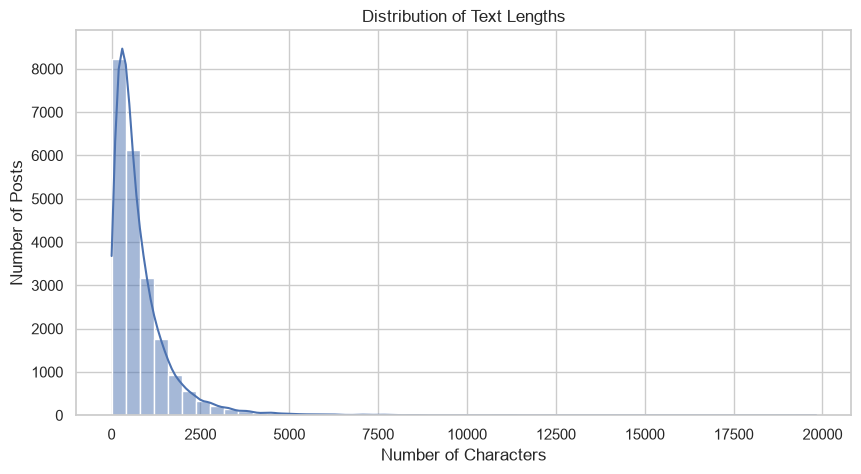

count    21832.000000
mean       802.759161
std        895.029651
min          3.000000
25%        276.000000
50%        536.000000
75%       1017.250000
max      19822.000000
Name: text_length, dtype: float64

In [9]:
# This cell creates a text length feature for EDA.
# Longer texts may contain more emotional context, while very short texts may be harder to classify.

df["text_length"] = df[TEXT_COLUMN].fillna("").astype(str).str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Posts")
plt.show()

df["text_length"].describe()

## 4. Create Multi-Label Targets

Some Kaggle versions already contain labels. Others contain a subreddit or class column. This notebook first looks for existing target columns. If they are not present, it creates weak labels using category keywords so the full pipeline can still run for demonstration and contribution purposes.

In [10]:
# Target categories for mental health classification.
CATEGORIES = ["Depression", "Anxiety", "Stress"]

print("Target categories:", CATEGORIES)

Target categories: ['Depression', 'Anxiety', 'Stress']


In [11]:
# This cell creates one binary column per mental health category.
# The dataset has a 'status' column with direct label names,
# so we map them to binary columns for multi-label classification.

CATEGORIES = ["Depression", "Anxiety", "Stress"]

def create_label_columns(dataframe):
    """Create Depression, Anxiety, Stress binary columns from the status column."""
    labeled_df = dataframe.copy()
    for category in CATEGORIES:
        labeled_df[category] = (labeled_df["status"] == category).astype(int)
    return labeled_df

df = create_label_columns(df)
df[CATEGORIES].head()

,Depression,Anxiety,Stress
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


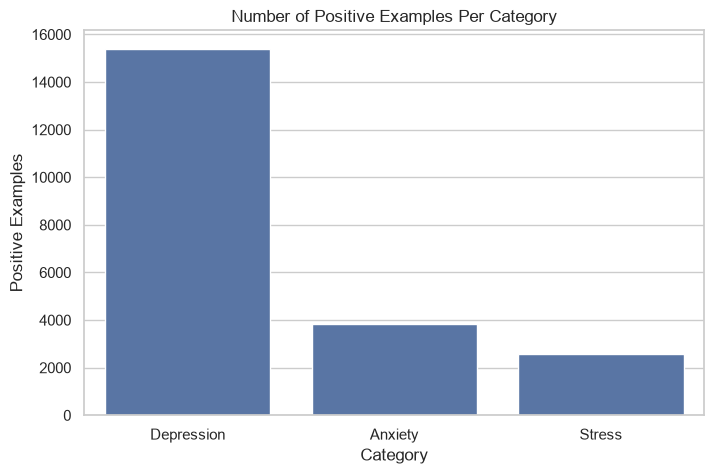

Depression    15404
Anxiety        3841
Stress         2587
dtype: int64

In [12]:
# This cell visualizes how many examples belong to each category.
# Label balance matters because rare categories are harder for the model to learn.

label_counts = df[CATEGORIES].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Number of Positive Examples Per Category")
plt.xlabel("Category")
plt.ylabel("Positive Examples")
plt.show()

label_counts

## 5. Text Preprocessing

Text preprocessing reduces noise by lowercasing, removing links, removing punctuation, tokenizing words, and removing common stopwords.

In [13]:
# This cell prepares the English stopword list.
# Stopwords are common words like 'the', 'is', and 'and' that often add little meaning for classification.

STOP_WORDS = set(stopwords.words("english"))

def clean_text(text):
    """Clean, tokenize, and remove stopwords from one text sample."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [token for token in tokens if token not in STOP_WORDS and len(token) > 2]
    return " ".join(tokens)


# Apply preprocessing to every text sample and store the result in a new column.
df["clean_text"] = df[TEXT_COLUMN].fillna("").apply(clean_text)

df[[TEXT_COLUMN, "clean_text"]].head()

,statement,clean_text
0,oh my gosh,gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,shifted focus something else still worried
4,"I'm restless and restless, it's been a month n...",restless restless month boy mean


## 6. Train-Test Split

We split the dataset so the model is trained on one part and evaluated on unseen data. This gives a more realistic estimate of performance.

In [14]:
# This cell creates input text X and multi-label target matrix y.
# We use clean_text as input because it has already been normalized.

model_df = df[df["clean_text"].str.len() > 0].copy()
X = model_df["clean_text"]
y = model_df[CATEGORIES]

# A fixed random_state makes results reproducible for contributors.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Some Kaggle files may have very few examples for a category such as Burnout.
# Logistic Regression needs at least one positive and one negative training example per label.
# The small synthetic rows below prevent training errors while keeping the real dataset unchanged.
synthetic_examples = {
    "Depression": "feeling hopeless sad empty worthless depressed",
    "Anxiety": "feeling anxious nervous worried panic fear",
    "Stress": "feeling stressed overwhelmed pressure deadline tension",
    "Burnout": "feeling burned out exhausted drained unmotivated fatigue",
}

for category in CATEGORIES:
    if y_train[category].nunique() < 2:
        positive_row = {label: 0 for label in CATEGORIES}
        positive_row[category] = 1

        X_train = pd.concat(
            [X_train, pd.Series([synthetic_examples[category], "neutral everyday text sample"])]
        )
        y_train = pd.concat(
            [y_train, pd.DataFrame([positive_row, {label: 0 for label in CATEGORIES}])],
            ignore_index=True,
        )
        print(f"Added tiny synthetic training support for rare category: {category}")

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])

Training examples: 17464
Testing examples: 4367


## 7. Model Training

This notebook uses TF-IDF plus Logistic Regression because it runs well on a normal CPU and does not require a GPU.

In [15]:
# This cell builds a machine learning pipeline.
# TF-IDF converts text into numeric features based on word importance.
# OneVsRestClassifier trains one Logistic Regression model for each category.

pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=10000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
            ),
        ),
        (
            "classifier",
            OneVsRestClassifier(
                LogisticRegression(max_iter=1000, class_weight="balanced")
            ),
        ),
    ]
)

# Train the complete pipeline on the training split.
pipeline.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 8. Evaluation

We evaluate the model with F1 score and AUC-ROC. F1 balances precision and recall, while AUC-ROC measures how well the model separates positive and negative examples.

In [16]:
# This cell generates predictions and probabilities for the test set.
# Predictions are 0/1 labels. Probabilities are used for risk scores and AUC-ROC.

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

# Print a detailed classification report for each label.
print(classification_report(y_test, y_pred, target_names=CATEGORIES, zero_division=0))

# Calculate overall micro and macro F1 scores.
micro_f1 = f1_score(y_test, y_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Micro F1 Score: {micro_f1:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

              precision    recall  f1-score   support

  Depression       0.95      0.90      0.92      3088
     Anxiety       0.75      0.88      0.81       786
      Stress       0.49      0.75      0.59       493

   micro avg       0.83      0.88      0.86      4367
   macro avg       0.73      0.84      0.78      4367
weighted avg       0.86      0.88      0.87      4367
 samples avg       0.84      0.88      0.85      4367

Micro F1 Score: 0.8558
Macro F1 Score: 0.7754


In [17]:
# This cell calculates AUC-ROC for each category.
# AUC-ROC may be skipped for a category if the test split contains only one class.

auc_scores = {}

for index, category in enumerate(CATEGORIES):
    if y_test[category].nunique() < 2:
        auc_scores[category] = np.nan
        print(f"{category}: AUC-ROC skipped because only one class is present in y_test.")
    else:
        auc_scores[category] = roc_auc_score(y_test[category], y_proba[:, index])
        print(f"{category}: AUC-ROC = {auc_scores[category]:.4f}")

auc_scores

Depression: AUC-ROC = 0.9578
Anxiety: AUC-ROC = 0.9699
Stress: AUC-ROC = 0.9178


{'Depression': 0.9577555884819342,
 'Anxiety': 0.9698623211421888,
 'Stress': 0.9177635058082122}

## 9. Risk Scores And Severity

The model outputs probabilities. We convert each probability to a 0-100 risk score and assign Low, Medium, or High severity.

In [18]:
# This cell defines risk score and severity helper functions.
# The same logic is mirrored in app.py so the notebook and UI behave consistently.

RISK_THRESHOLDS = {
    category: {"medium": 40, "high": 70}
    for category in CATEGORIES
}

def severity_from_score(score, category):
    """Convert a numeric risk score into Low, Medium, or High severity."""
    if score >= RISK_THRESHOLDS[category]["high"]:
        return "High"
    if score >= RISK_THRESHOLDS[category]["medium"]:
        return "Medium"
    return "Low"


def predict_risk(text):
    """Return risk scores and severity labels for one input text."""
    cleaned = clean_text(text)
    probabilities = pipeline.predict_proba([cleaned])[0]
    results = {}

    for index, category in enumerate(CATEGORIES):
        score = round(probabilities[index] * 100, 2)
        results[category] = {
            "risk_score": score,
            "severity": severity_from_score(score, category),
        }

    return results


sample_text = "I feel exhausted, anxious, and overwhelmed by everything I need to do."
predict_risk(sample_text)

{'Depression': {'risk_score': np.float64(18.81), 'severity': 'Low'},
 'Anxiety': {'risk_score': np.float64(61.82), 'severity': 'Medium'},
 'Stress': {'risk_score': np.float64(60.05), 'severity': 'Medium'}}

## 10. LIME Explainability

LIME explains one prediction by showing which words pushed the model toward or away from a selected category.

In [19]:
# This cell creates a helper for LIME explanations.
# LIME expects a function that returns a two-column probability array for one class.
# We create a small wrapper so LIME can explain each mental health category separately.

explainer = LimeTextExplainer(class_names=["Not Present", "Present"])

def make_lime_predict_function(category_index):
    """Build a prediction function for one category so LIME can explain it."""
    def predict_function(texts):
        cleaned_texts = [clean_text(text) for text in texts]
        positive_probabilities = pipeline.predict_proba(cleaned_texts)[:, category_index]
        return np.column_stack([1 - positive_probabilities, positive_probabilities])

    return predict_function


# Pick one example from the test set and explain the Depression prediction.
example_text = X_test.iloc[0]
category_to_explain = "Depression"
category_index = CATEGORIES.index(category_to_explain)

explanation = explainer.explain_instance(
    example_text,
    make_lime_predict_function(category_index),
    num_features=10,
)

print("Text being explained:")
print(example_text)
print("\nTop explanation features:")
explanation.as_list()

Text being explained:
pins needles sensation year old soon black male probably font healthiest lifestyle doctor past days pins needles sensation kind like numbness like see thing feel way smoked weed pretty frequently past weeks means heavy smoker wondering could symptom early onset diabetes sure severe though perhaps carpal tunnel thumb giving problem several years got jammed football perhaps healed properly help advice would greatly appreciated

Top explanation features:


[(np.str_('sensation'), -0.055685236774600716),
 (np.str_('needles'), -0.05423279624695753),
 (np.str_('symptom'), 0.051323144404470666),
 (np.str_('thing'), 0.0409420037037021),
 (np.str_('diabetes'), -0.038600608573517485),
 (np.str_('greatly'), -0.03579207896250643),
 (np.str_('days'), -0.03197934431820801),
 (np.str_('perhaps'), -0.0315274169942367),
 (np.str_('feel'), 0.019676578996041662),
 (np.str_('way'), 0.019415820755050477)]

## 11. Save Model Artifacts

The trained model and thresholds are saved so the Gradio app can load them without retraining.

In [20]:
# This cell saves the trained pipeline and risk thresholds.
# app.py expects these files inside the models/ directory.

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(pipeline, MODEL_DIR / "mental_health_tfidf_model.joblib")
joblib.dump(RISK_THRESHOLDS, MODEL_DIR / "risk_thresholds.joblib")

print(f"Saved model files to: {MODEL_DIR}")

Saved model files to: c:\Users\admin\Documents\GitHub\ML-CaPsule\Mental Health Text Analysis\models


## 12. Final Notes

This project is for education and open source contribution only. It should not be used as a medical diagnosis system. Text classification can miss context, sarcasm, crisis signals, and personal details that require human support.